# Fixed Ratio IPO vs Standard IPO Comparison

이 notebook은 Qwen3-0.6B 실험에서 `target_ratio=0.6/0.7/0.8`로 고정한 IPO 모델들을 standard IPO baseline과 비교합니다.

포함 내용:

1. Fixed-ratio 학습 로그 요약
2. Train loss, actual ratio, reward accuracy, reward margin curve
3. Standard IPO 대비 benchmark 비교
4. Task별 delta 및 평균 점수 ranking


In [48]:

from pathlib import Path
import os
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    sns = None

ROOT = Path.cwd()
os.environ["HF_HOME"] = str(ROOT / ".hf_cache")
os.environ["HF_DATASETS_CACHE"] = str(ROOT / ".hf_cache" / "datasets")
os.environ["PYTHONDONTWRITEBYTECODE"] = "1"

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

BENCHMARK_CSV = ROOT / "outputs" / "eval_trained_ipo_variants" / "benchmark_comparison.csv"
TRAINING_SUMMARY_CSV = ROOT / "outputs" / "eval_trained_ipo_variants" / "training_log_summary.csv"
benchmark_all = pd.read_csv(BENCHMARK_CSV)
training_all = pd.read_csv(TRAINING_SUMMARY_CSV)

def show_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)

def latest_state_path(run_dir):
    paths = sorted(
        Path(run_dir).glob("checkpoint-*/trainer_state.json"),
        key=lambda p: int(re.search(r"checkpoint-(\d+)", str(p)).group(1)),
    )
    return paths[-1] if paths else None

def load_state(path):
    with open(path, "r") as f:
        return json.load(f)

def load_curves(run_rows):
    rows = []
    for row in run_rows:
        state_path = latest_state_path(row["run_dir"])
        if state_path is None:
            continue
        state = load_state(state_path)
        for item in state.get("log_history", []):
            step = item.get("step")
            if step is None:
                continue
            if "loss" in item:
                rows.append({
                    "model": row["model"],
                    "split": "train",
                    "step": step,
                    "epoch": item.get("epoch"),
                    "loss": item.get("loss"),
                    "actual_ratio": item.get("target_ratio/actual"),
                    "reward_accuracy": item.get("rewards/accuracies"),
                    "reward_margin": item.get("rewards/margins"),
                    "learning_rate": item.get("learning_rate"),
                    "grad_norm": item.get("grad_norm"),
                })
            if "eval_loss" in item:
                rows.append({
                    "model": row["model"],
                    "split": "eval",
                    "step": step,
                    "epoch": item.get("epoch"),
                    "loss": item.get("eval_loss"),
                    "actual_ratio": item.get("eval_target_ratio/actual"),
                    "reward_accuracy": item.get("eval_rewards/accuracies"),
                    "reward_margin": item.get("eval_rewards/margins"),
                    "learning_rate": np.nan,
                    "grad_norm": np.nan,
                })
    return pd.DataFrame(rows)

def lineplot_metric(curves, metric, title=None, ylabel=None, ylim=None):
    df = curves.dropna(subset=[metric]).copy()
    plt.figure(figsize=(11, 4.8))
    if sns:
        sns.lineplot(data=df, x="step", y=metric, hue="model", style="split")
    else:
        for (model, split), g in df.groupby(["model", "split"]):
            plt.plot(g["step"], g[metric], label=f"{model} {split}")
        plt.legend()
    plt.title(title or metric)
    plt.xlabel("step")
    plt.ylabel(ylabel or metric)
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

def lineplot_train_metric(curves, metric, title=None, ylabel=None, ylim=None):
    df = curves[curves["split"].eq("train")].dropna(subset=[metric]).copy()
    plt.figure(figsize=(11, 4.8))
    if sns:
        sns.lineplot(data=df, x="step", y=metric, hue="model")
    else:
        for model, g in df.groupby("model"):
            plt.plot(g["step"], g[metric], label=model)
        plt.legend()
    plt.title(title or metric)
    plt.xlabel("step")
    plt.ylabel(ylabel or metric)
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()


In [49]:
def plot_train_actual_ratio(curves, title="Train Actual Ratio", ylim=None):
    train_df = curves[(curves["split"].eq("train")) & curves["actual_ratio"].notna()].copy()
    if train_df.empty:
        print("No train actual_ratio values found.")
        return
    plt.figure(figsize=(10.5, 4.8))
    if sns:
        sns.lineplot(data=train_df, x="step", y="actual_ratio", hue="model")
    else:
        for model, g in train_df.groupby("model"):
            plt.plot(g["step"], g["actual_ratio"], label=model)
        plt.legend()
    plt.title(title)
    plt.xlabel("step")
    plt.ylabel("train actual_ratio")
    if ylim:
        plt.ylim(*ylim)
    plt.tight_layout()
    plt.show()

In [50]:

FIXED_RUN_ROOT = ROOT / "outputs" / "fixed_ratio_ipo"
run_rows = []
for ratio in [0.6, 0.7, 0.8]:
    run_dir = FIXED_RUN_ROOT / f"ratio_{ratio:.1f}_e3_bs8_beta0.01_lr5e-7"
    run_rows.append({
        "model": f"ratio={ratio:.1f}",
        "objective": "target_ratio",
        "target_ratio": ratio,
        "run_dir": run_dir,
        "final_dir": run_dir / "final",
        "latest_state": latest_state_path(run_dir),
        "has_final": (run_dir / "final" / "model.safetensors").exists(),
    })

runs = pd.DataFrame(run_rows)
runs


,model,objective,target_ratio,run_dir,final_dir,latest_state,has_final
0,ratio=0.6,target_ratio,0.6,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,True
1,ratio=0.7,target_ratio,0.7,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,True
2,ratio=0.8,target_ratio,0.8,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,/home/cvip/qwen3_ipo_exp/outputs/fixed_ratio_i...,True


In [51]:

summary = training_all[training_all["model"].isin(["ratio=0.6", "ratio=0.7", "ratio=0.8"])].copy()
summary = summary.rename(columns={"chosen_target_ratio": "target_ratio"})
cols = [
    "model", "objective", "target_ratio", "global_step", "epoch",
    "final_train_loss", "final_eval_loss",
    "final_train_actual_ratio", "final_eval_actual_ratio",
    "final_eval_reward_accuracy", "final_eval_margin",
]
summary[cols]


,model,objective,target_ratio,global_step,epoch,final_train_loss,final_eval_loss,final_train_actual_ratio,final_eval_actual_ratio,final_eval_reward_accuracy,final_eval_margin
0,ratio=0.6,target_ratio,0.6,2709,3.0,0.010069,0.200775,0.591715,0.497825,0.475532,-0.008959
1,ratio=0.7,target_ratio,0.7,2709,3.0,0.081626,0.862884,0.671969,0.499815,0.520745,-0.002530
2,ratio=0.8,target_ratio,0.8,2709,3.0,0.349112,2.306138,0.736406,0.501552,0.520745,0.001503


In [52]:

curves = load_curves(run_rows)
curves.to_csv(ROOT / "outputs" / "analysis_ipo_variants" / "fixed_ratio_training_curves.csv", index=False)
curves.tail()


,model,split,step,epoch,loss,actual_ratio,reward_accuracy,reward_margin,learning_rate,grad_norm
889,ratio=0.8,train,2680,2.967885,0.353967,0.728454,0.962500,1.034444,5.537099e-09,75.677200
890,ratio=0.8,train,2690,2.978959,0.366586,0.728829,0.962500,1.036901,3.691399e-09,190.755173
891,ratio=0.8,train,2700,2.990033,0.349112,0.736406,0.975000,1.086174,1.845700e-09,59.622700
892,ratio=0.8,eval,2700,2.990033,2.309186,0.501267,0.512766,0.000121,NaN,NaN
893,ratio=0.8,eval,2709,3.000000,2.306138,0.501552,0.520745,0.001503,NaN,NaN


## Train/Eval Reward Accuracy 분리 및 Gap

`reward_accuracy`는 benchmark accuracy가 아니라 preference pair에서 `chosen reward > rejected reward`인 비율입니다.  
Train과 eval의 범위가 크게 달라 한 그래프에 겹치면 차이가 잘 안 보이므로, 아래에서는 train/eval을 분리하고 마지막으로 train-eval gap을 확인합니다.

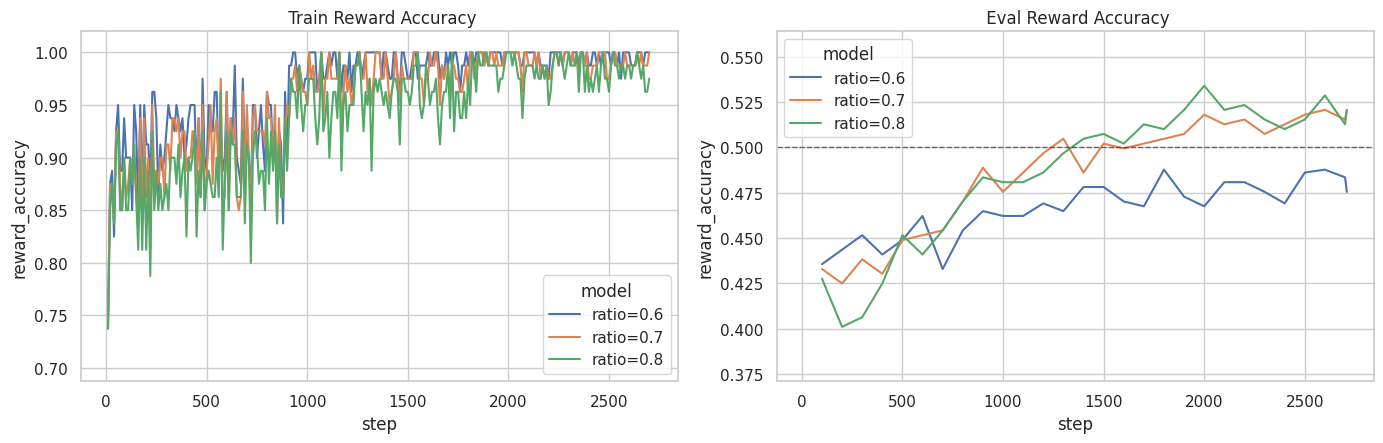

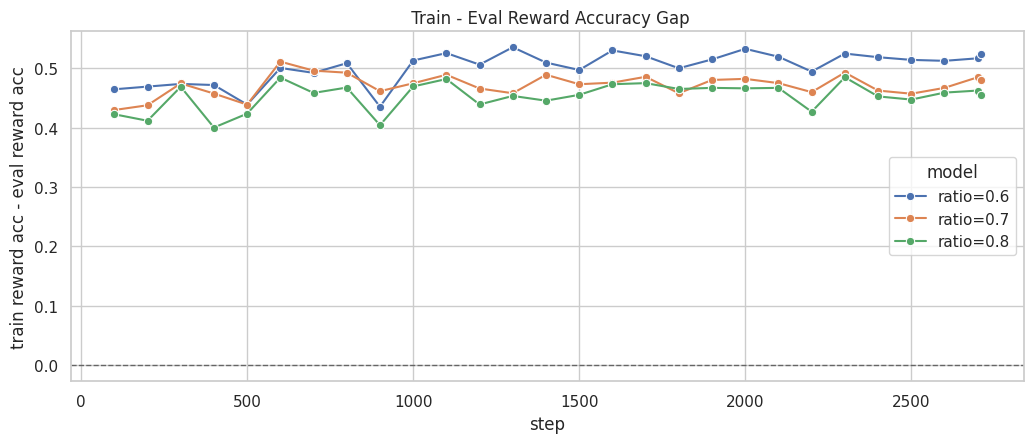

,model,step,reward_accuracy_train,reward_accuracy_eval,train_minus_eval
27,ratio=0.6,2709,1.000,0.4755,0.5245
55,ratio=0.7,2709,1.000,0.5207,0.4793
83,ratio=0.8,2709,0.975,0.5207,0.4543


In [53]:
def plot_train_eval_accuracy_separately(curves, title_prefix=""):
    acc = curves.dropna(subset=["reward_accuracy"]).copy()
    if acc.empty:
        print("No reward_accuracy values found.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharex=True)
    for ax, split, ylim in [
        (axes[0], "train", None),
        (axes[1], "eval", None),
    ]:
        split_df = acc[acc["split"].eq(split)]
        if split_df.empty:
            ax.set_title(f"{split}: no data")
            continue
        if sns:
            sns.lineplot(data=split_df, x="step", y="reward_accuracy", hue="model", ax=ax)
        else:
            for model, g in split_df.groupby("model"):
                ax.plot(g["step"], g["reward_accuracy"], label=model)
            ax.legend()
        ax.set_title(f"{title_prefix} {split.capitalize()} Reward Accuracy")
        ax.set_xlabel("step")
        ax.set_ylabel("reward_accuracy")
        if split == "train":
            low = max(0.0, split_df["reward_accuracy"].min() - 0.05)
            ax.set_ylim(low, 1.02)
        else:
            low = max(0.0, split_df["reward_accuracy"].min() - 0.03)
            high = min(1.0, split_df["reward_accuracy"].max() + 0.03)
            ax.set_ylim(low, high)
        ax.axhline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.5)
    plt.tight_layout()
    plt.show()


def plot_accuracy_gap(curves, title_prefix=""):
    acc = curves.dropna(subset=["reward_accuracy"]).copy()
    if acc.empty:
        print("No reward_accuracy values found.")
        return pd.DataFrame()

    wide = (
        acc.pivot_table(index=["model", "step"], columns="split", values="reward_accuracy", aggfunc="last")
        .reset_index()
    )
    if "train" not in wide.columns or "eval" not in wide.columns:
        print("Need both train and eval reward_accuracy values to compute gap.")
        return wide

    # Eval is logged less often than train. Forward-fill train value at eval steps per model.
    rows = []
    for model, model_acc in acc.groupby("model"):
        train = model_acc[model_acc["split"].eq("train")][["step", "reward_accuracy"]].sort_values("step")
        eval_df = model_acc[model_acc["split"].eq("eval")][["step", "reward_accuracy"]].sort_values("step")
        if train.empty or eval_df.empty:
            continue
        merged = pd.merge_asof(
            eval_df,
            train,
            on="step",
            direction="backward",
            suffixes=("_eval", "_train"),
        )
        merged["model"] = model
        merged["train_minus_eval"] = merged["reward_accuracy_train"] - merged["reward_accuracy_eval"]
        rows.append(merged)

    gap_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    if gap_df.empty:
        print("No gap rows computed.")
        return gap_df

    plt.figure(figsize=(10.5, 4.6))
    if sns:
        sns.lineplot(data=gap_df, x="step", y="train_minus_eval", hue="model", marker="o")
    else:
        for model, g in gap_df.groupby("model"):
            plt.plot(g["step"], g["train_minus_eval"], marker="o", label=model)
        plt.legend()
    plt.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.5)
    plt.title(f"{title_prefix} Train - Eval Reward Accuracy Gap")
    plt.xlabel("step")
    plt.ylabel("train reward acc - eval reward acc")
    plt.tight_layout()
    plt.show()

    final_gap = gap_df.sort_values("step").groupby("model").tail(1)[[
        "model", "step", "reward_accuracy_train", "reward_accuracy_eval", "train_minus_eval"
    ]]
    display(final_gap.sort_values("train_minus_eval", ascending=False).round(4))
    return gap_df

plot_train_eval_accuracy_separately(curves, title_prefix="")
accuracy_gap = plot_accuracy_gap(curves, title_prefix="")

### Actual Ratio Plot 기준

Eval actual ratio는 대부분 0.5 근처에 머물러 방법 비교 시 시각적으로 큰 의미가 적으므로, actual ratio 그래프에서는 train 값만 표시합니다. Eval actual ratio는 summary table에서만 참고합니다.

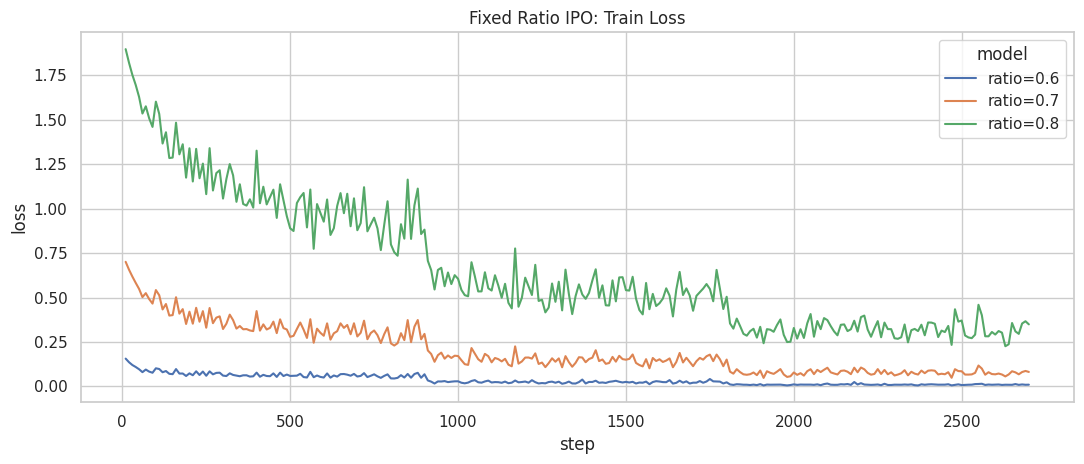

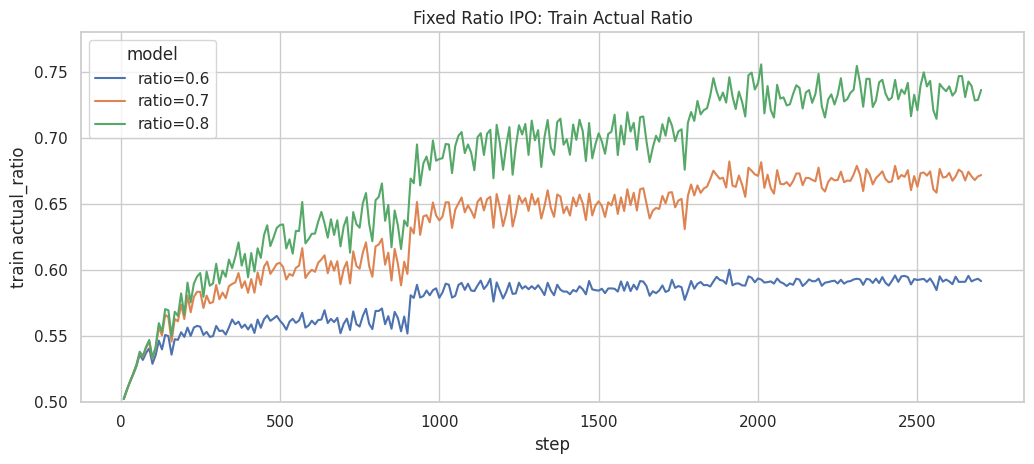

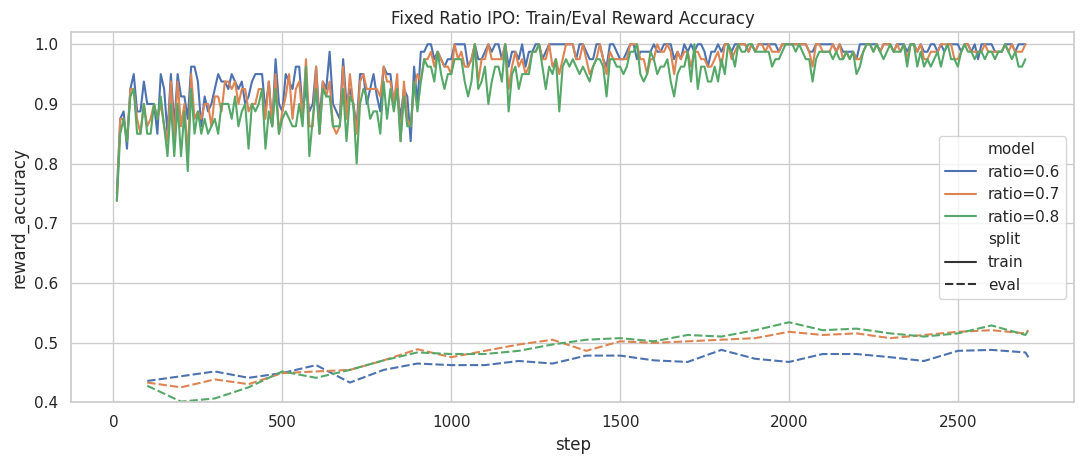

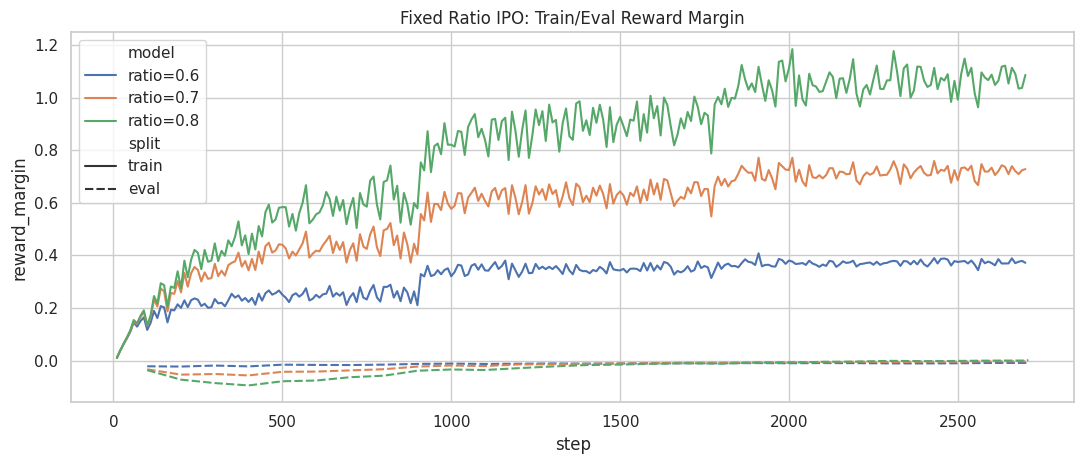

In [54]:

lineplot_train_metric(curves, "loss", "Fixed Ratio IPO: Train Loss")
plot_train_actual_ratio(curves, "Fixed Ratio IPO: Train Actual Ratio", ylim=(0.50, 0.78))
lineplot_metric(curves, "reward_accuracy", "Fixed Ratio IPO: Train/Eval Reward Accuracy", ylim=(0.4, 1.02))
lineplot_metric(curves, "reward_margin", "Fixed Ratio IPO: Train/Eval Reward Margin")


## Benchmark: Fixed Ratio vs Standard IPO

Standard IPO baseline과 fixed ratio 모델들의 task별 benchmark를 비교합니다.

In [55]:

fixed_cols = ["IPO", "ratio=0.6", "ratio=0.7", "ratio=0.8"]
benchmark = benchmark_all[["Task", "Metric", *fixed_cols]].copy()
for col in ["ratio=0.6", "ratio=0.7", "ratio=0.8"]:
    benchmark[f"{col} - IPO"] = benchmark[col] - benchmark["IPO"]
benchmark.to_csv(ROOT / "outputs" / "analysis_ipo_variants" / "fixed_ratio_vs_ipo_benchmark.csv", index=False)
benchmark


,Task,Metric,IPO,ratio=0.6,ratio=0.7,ratio=0.8,ratio=0.6 - IPO,ratio=0.7 - IPO,ratio=0.8 - IPO
0,ARC-Challenge,acc_norm,0.3968,0.4027,0.4087,0.4044,0.0059,0.0119,0.0076
1,ARC-Easy,acc_norm,0.6700,0.6612,0.6498,0.6389,-0.0088,-0.0202,-0.0311
2,HellaSwag,acc_norm,0.5540,0.5650,0.5681,0.5707,0.0110,0.0141,0.0167
3,TruthfulQA MC2,acc,0.4576,0.4789,0.4904,0.4957,0.0213,0.0328,0.0381
4,Winogrande,acc,0.5935,0.5848,0.5746,0.5770,-0.0087,-0.0189,-0.0165


In [56]:

ranking = benchmark[fixed_cols].mean().rename("mean_score").sort_values(ascending=False)
delta_ranking = (ranking - ranking["IPO"]).rename("delta_vs_IPO")
pd.concat([ranking, delta_ranking], axis=1)


,mean_score,delta_vs_IPO
ratio=0.6,0.53852,0.00414
ratio=0.7,0.53832,0.00394
ratio=0.8,0.53734,0.00296
IPO,0.53438,0.00000


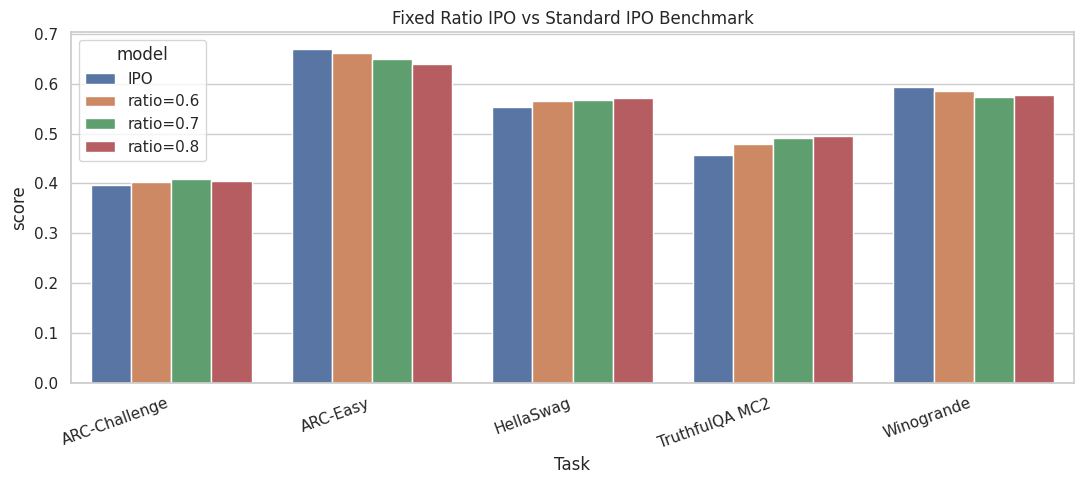

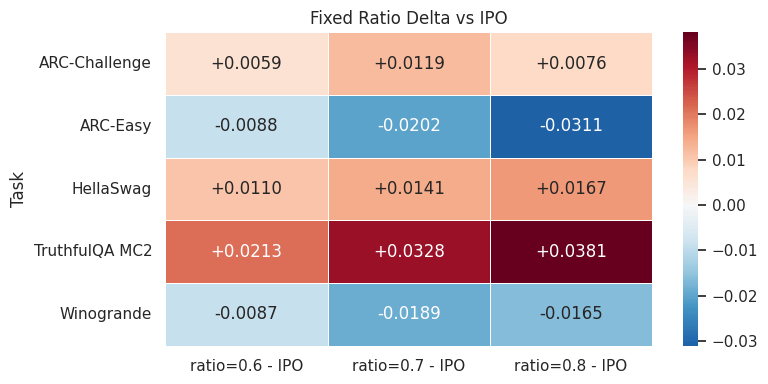

In [57]:

plot_df = benchmark.melt(
    id_vars=["Task", "Metric"],
    value_vars=fixed_cols,
    var_name="model",
    value_name="score",
)
plt.figure(figsize=(11, 5))
if sns:
    sns.barplot(data=plot_df, x="Task", y="score", hue="model")
else:
    for model, g in plot_df.groupby("model"):
        plt.plot(g["Task"], g["score"], marker="o", label=model)
    plt.legend()
plt.xticks(rotation=20, ha="right")
plt.title("Fixed Ratio IPO vs Standard IPO Benchmark")
plt.tight_layout()
plt.show()

heatmap_df = benchmark.set_index("Task")[["ratio=0.6 - IPO", "ratio=0.7 - IPO", "ratio=0.8 - IPO"]]
plt.figure(figsize=(8, 4))
if sns:
    sns.heatmap(heatmap_df, annot=True, fmt="+.4f", cmap="RdBu_r", center=0, linewidths=0.5)
else:
    plt.imshow(heatmap_df.values, aspect="auto", cmap="RdBu_r")
    plt.colorbar()
    plt.xticks(range(len(heatmap_df.columns)), heatmap_df.columns, rotation=30, ha="right")
    plt.yticks(range(len(heatmap_df.index)), heatmap_df.index)
plt.title("Fixed Ratio Delta vs IPO")
plt.tight_layout()
plt.show()


## 해석 기준

- `train actual ratio`가 target ratio를 따라 올라가면 학습 objective는 train set에서 작동한 것입니다.
- `eval actual ratio`가 0.5 근처라면 validation pair에서는 policy-reference gap 차이가 크게 형성되지 않은 것입니다.
- benchmark 평균이 IPO보다 높으면 fixed ratio가 downstream 성능 보존에 도움이 된 것으로 해석할 수 있습니다.

## Benchmark Task 설명

아래 표는 사용한 benchmark task가 각각 어떤 능력을 평가하는지 정리한 것입니다.

In [58]:
task_descriptions = pd.DataFrame([
    {
        "Task": "ARC-Challenge",
        "Metric": "acc_norm",
        "평가 능력": "어려운 과학/상식 추론",
        "설명": "ARC 과학 객관식 문제 중 모델이 자주 틀리는 어려운 문제 세트입니다. 추론 난이도가 높아 preference tuning 이후 일반 추론 능력이 유지되는지 보기 좋습니다.",
    },
    {
        "Task": "ARC-Easy",
        "Metric": "acc_norm",
        "평가 능력": "기초 과학/상식 추론",
        "설명": "ARC보다 쉬운 과학 객관식 문제입니다. 기본적인 상식과 과학 지식 보존 여부를 확인합니다.",
    },
    {
        "Task": "HellaSwag",
        "Metric": "acc_norm",
        "평가 능력": "문맥 기반 상식 추론",
        "설명": "주어진 상황 뒤에 올 가장 자연스러운 문장을 고르는 task입니다. 사건 흐름과 문맥 이해 능력을 봅니다.",
    },
    {
        "Task": "TruthfulQA MC2",
        "Metric": "acc",
        "평가 능력": "진실성 / 환각 억제",
        "설명": "사람들이 오해하기 쉬운 질문에서 사실에 가까운 답을 고르는 task입니다. 선호 학습 이후 truthfulness가 유지되거나 개선되는지 봅니다.",
    },
    {
        "Task": "Winogrande",
        "Metric": "acc",
        "평가 능력": "대명사/문장 의미 추론",
        "설명": "문장 속 대명사나 빈칸이 무엇을 가리키는지 고르는 task입니다. 문법뿐 아니라 문맥과 상식 추론이 필요합니다.",
    },
])
task_descriptions

,Task,Metric,평가 능력,설명
0,ARC-Challenge,acc_norm,어려운 과학/상식 추론,ARC 과학 객관식 문제 중 모델이 자주 틀리는 어려운 문제 세트입니다. 추론 난이...
1,ARC-Easy,acc_norm,기초 과학/상식 추론,ARC보다 쉬운 과학 객관식 문제입니다. 기본적인 상식과 과학 지식 보존 여부를 확...
2,HellaSwag,acc_norm,문맥 기반 상식 추론,주어진 상황 뒤에 올 가장 자연스러운 문장을 고르는 task입니다. 사건 흐름과 문...
3,TruthfulQA MC2,acc,진실성 / 환각 억제,사람들이 오해하기 쉬운 질문에서 사실에 가까운 답을 고르는 task입니다. 선호 학...
4,Winogrande,acc,대명사/문장 의미 추론,문장 속 대명사나 빈칸이 무엇을 가리키는지 고르는 task입니다. 문법뿐 아니라 문...


## Task별 Best Model 요약

각 benchmark task에서 standard IPO와 비교했을 때 어떤 variant가 가장 좋은지 정리합니다.

In [59]:
# Fixed ratio notebook: task별로 standard IPO 대비 가장 좋은 fixed-ratio 모델을 정리합니다.
task_cols = ["ratio=0.6", "ratio=0.7", "ratio=0.8"]
task_summary_rows = []
for _, row in benchmark.iterrows():
    scores = row[task_cols]
    best_model = scores.idxmax()
    best_score = scores.max()
    ipo_score = row["IPO"]
    task_summary_rows.append({
        "Task": row["Task"],
        "Metric": row["Metric"],
        "Standard IPO": ipo_score,
        "Best fixed ratio model": best_model,
        "Best fixed ratio score": best_score,
        "Delta vs IPO": best_score - ipo_score,
        "해석": "fixed ratio가 IPO보다 높음" if best_score > ipo_score else "IPO가 fixed ratio 이상",
    })
fixed_task_summary = pd.DataFrame(task_summary_rows)
fixed_task_summary

,Task,Metric,Standard IPO,Best fixed ratio model,Best fixed ratio score,Delta vs IPO,해석
0,ARC-Challenge,acc_norm,0.3968,ratio=0.7,0.4087,0.0119,fixed ratio가 IPO보다 높음
1,ARC-Easy,acc_norm,0.6700,ratio=0.6,0.6612,-0.0088,IPO가 fixed ratio 이상
2,HellaSwag,acc_norm,0.5540,ratio=0.8,0.5707,0.0167,fixed ratio가 IPO보다 높음
3,TruthfulQA MC2,acc,0.4576,ratio=0.8,0.4957,0.0381,fixed ratio가 IPO보다 높음
4,Winogrande,acc,0.5935,ratio=0.6,0.5848,-0.0087,IPO가 fixed ratio 이상
